In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
yaml_content = """
train: /content/drive/MyDrive/Data Augmentation/train/images
val: /content/drive/MyDrive/Annotated Dataset/valid/images
test: /content/drive/MyDrive/Annotated Dataset/test/images

nc: 8
names:
  - Chicken Bun
  - Chicken Cutlet
  - Chicken Pastry
  - Chicken Rolls
  - Chicken Rotti
  - Iced Coffee
  - Milk Rice
  - Pizza - Cheese Lovers
"""

# Save YAML into working directory
with open("data.yaml", "w") as f:
    f.write(yaml_content)


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
model = YOLO("yolov8n.pt")

In [8]:
results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project="food_detection",
    name="yolov8n_run1"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0

# Validation Metrics

In [9]:
metrics = model.val(data="data.yaml", split="test")
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 0.2±0.1 MB/s, size: 38.6 KB)
val: Scanning /content/drive/MyDrive/Annotated Dataset/test/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.2s/it 3.2s
                   all          8          8      0.935          1      0.995      0.983
           Chicken Bun          1          1      0.944          1      0.995      0.995
        Chicken Cutlet          1          1      0.924          1      0.995      0.995
        Chicken Pastry          1          1      0.971          1      0.995      0.995
         Chicken Rolls          1          1      0.909          1      0.995      0.995
         Chicken Rotti          1      

# Test

In [10]:
results = model.predict(
    source="/content/drive/MyDrive/Annotated Dataset/test/images",
    save=True,
    conf=0.25
)


image 1/8 /content/drive/MyDrive/Annotated Dataset/test/images/14.jpg: 640x640 1 Chicken Pastry, 334.9ms
image 2/8 /content/drive/MyDrive/Annotated Dataset/test/images/30.jpg: 640x640 1 Chicken Rolls, 324.4ms
image 3/8 /content/drive/MyDrive/Annotated Dataset/test/images/34.jpg: 640x640 1 Pizza - Cheese Lovers, 334.7ms
image 4/8 /content/drive/MyDrive/Annotated Dataset/test/images/41.jpg: 640x640 1 Chicken Cutlet, 315.8ms
image 5/8 /content/drive/MyDrive/Annotated Dataset/test/images/55.jpg: 640x640 1 Chicken Bun, 324.7ms
image 6/8 /content/drive/MyDrive/Annotated Dataset/test/images/58.jpg: 640x640 1 Milk Rice, 346.8ms
image 7/8 /content/drive/MyDrive/Annotated Dataset/test/images/73.jpg: 640x640 1 Chicken Rotti, 379.7ms
image 8/8 /content/drive/MyDrive/Annotated Dataset/test/images/78.jpg: 640x640 1 Iced Coffee, 349.6ms
Speed: 3.7ms preprocess, 338.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


# Training / Validation Visualization


--- results.png ---


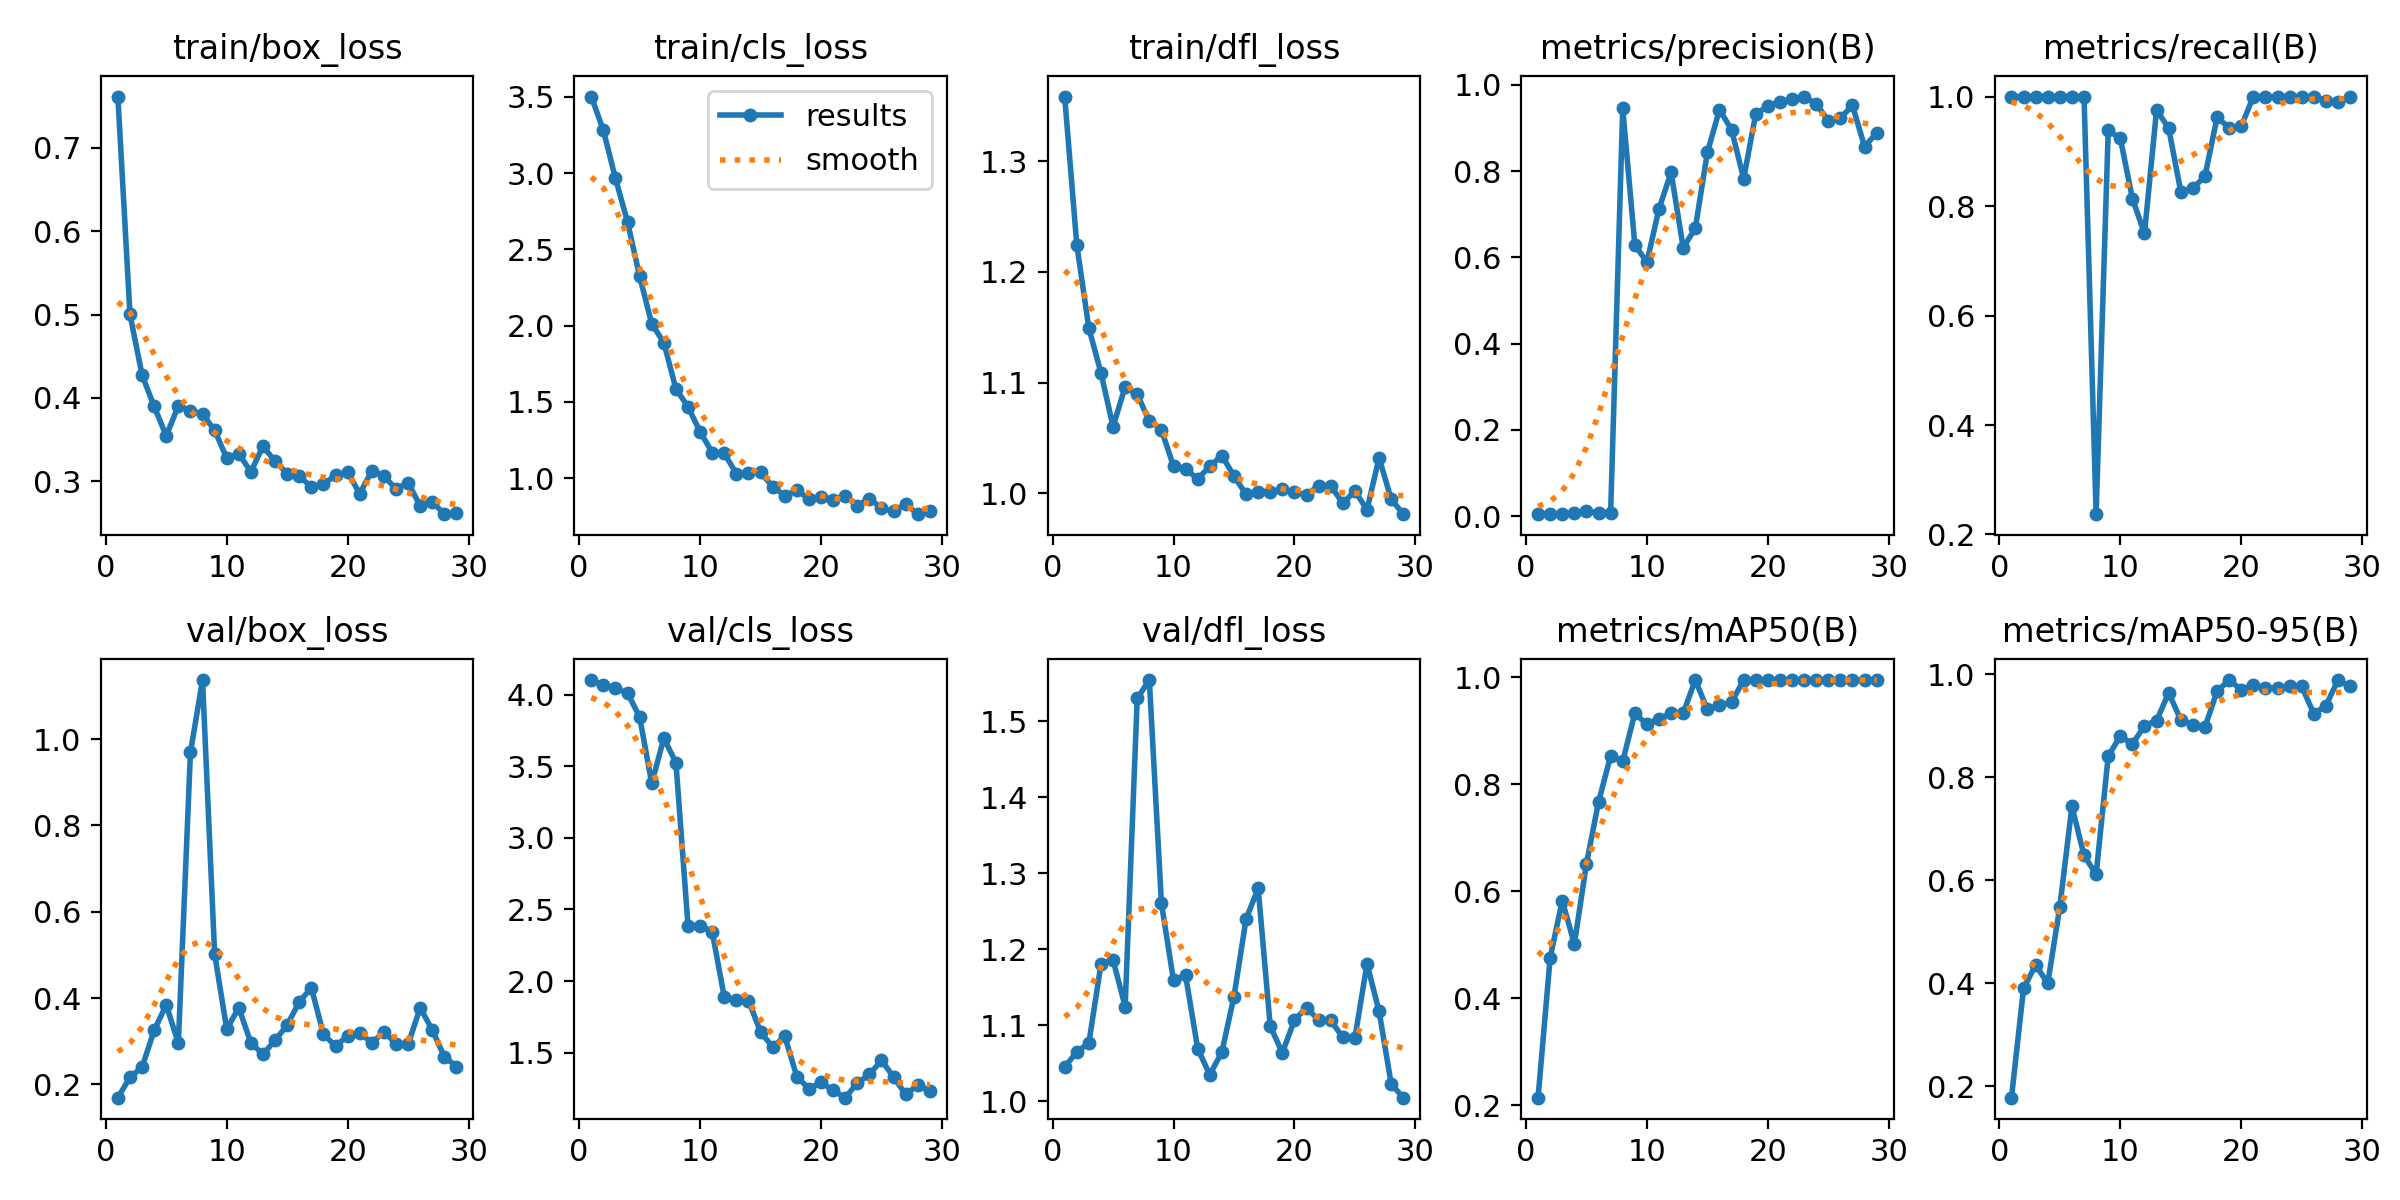


--- confusion_matrix.png ---


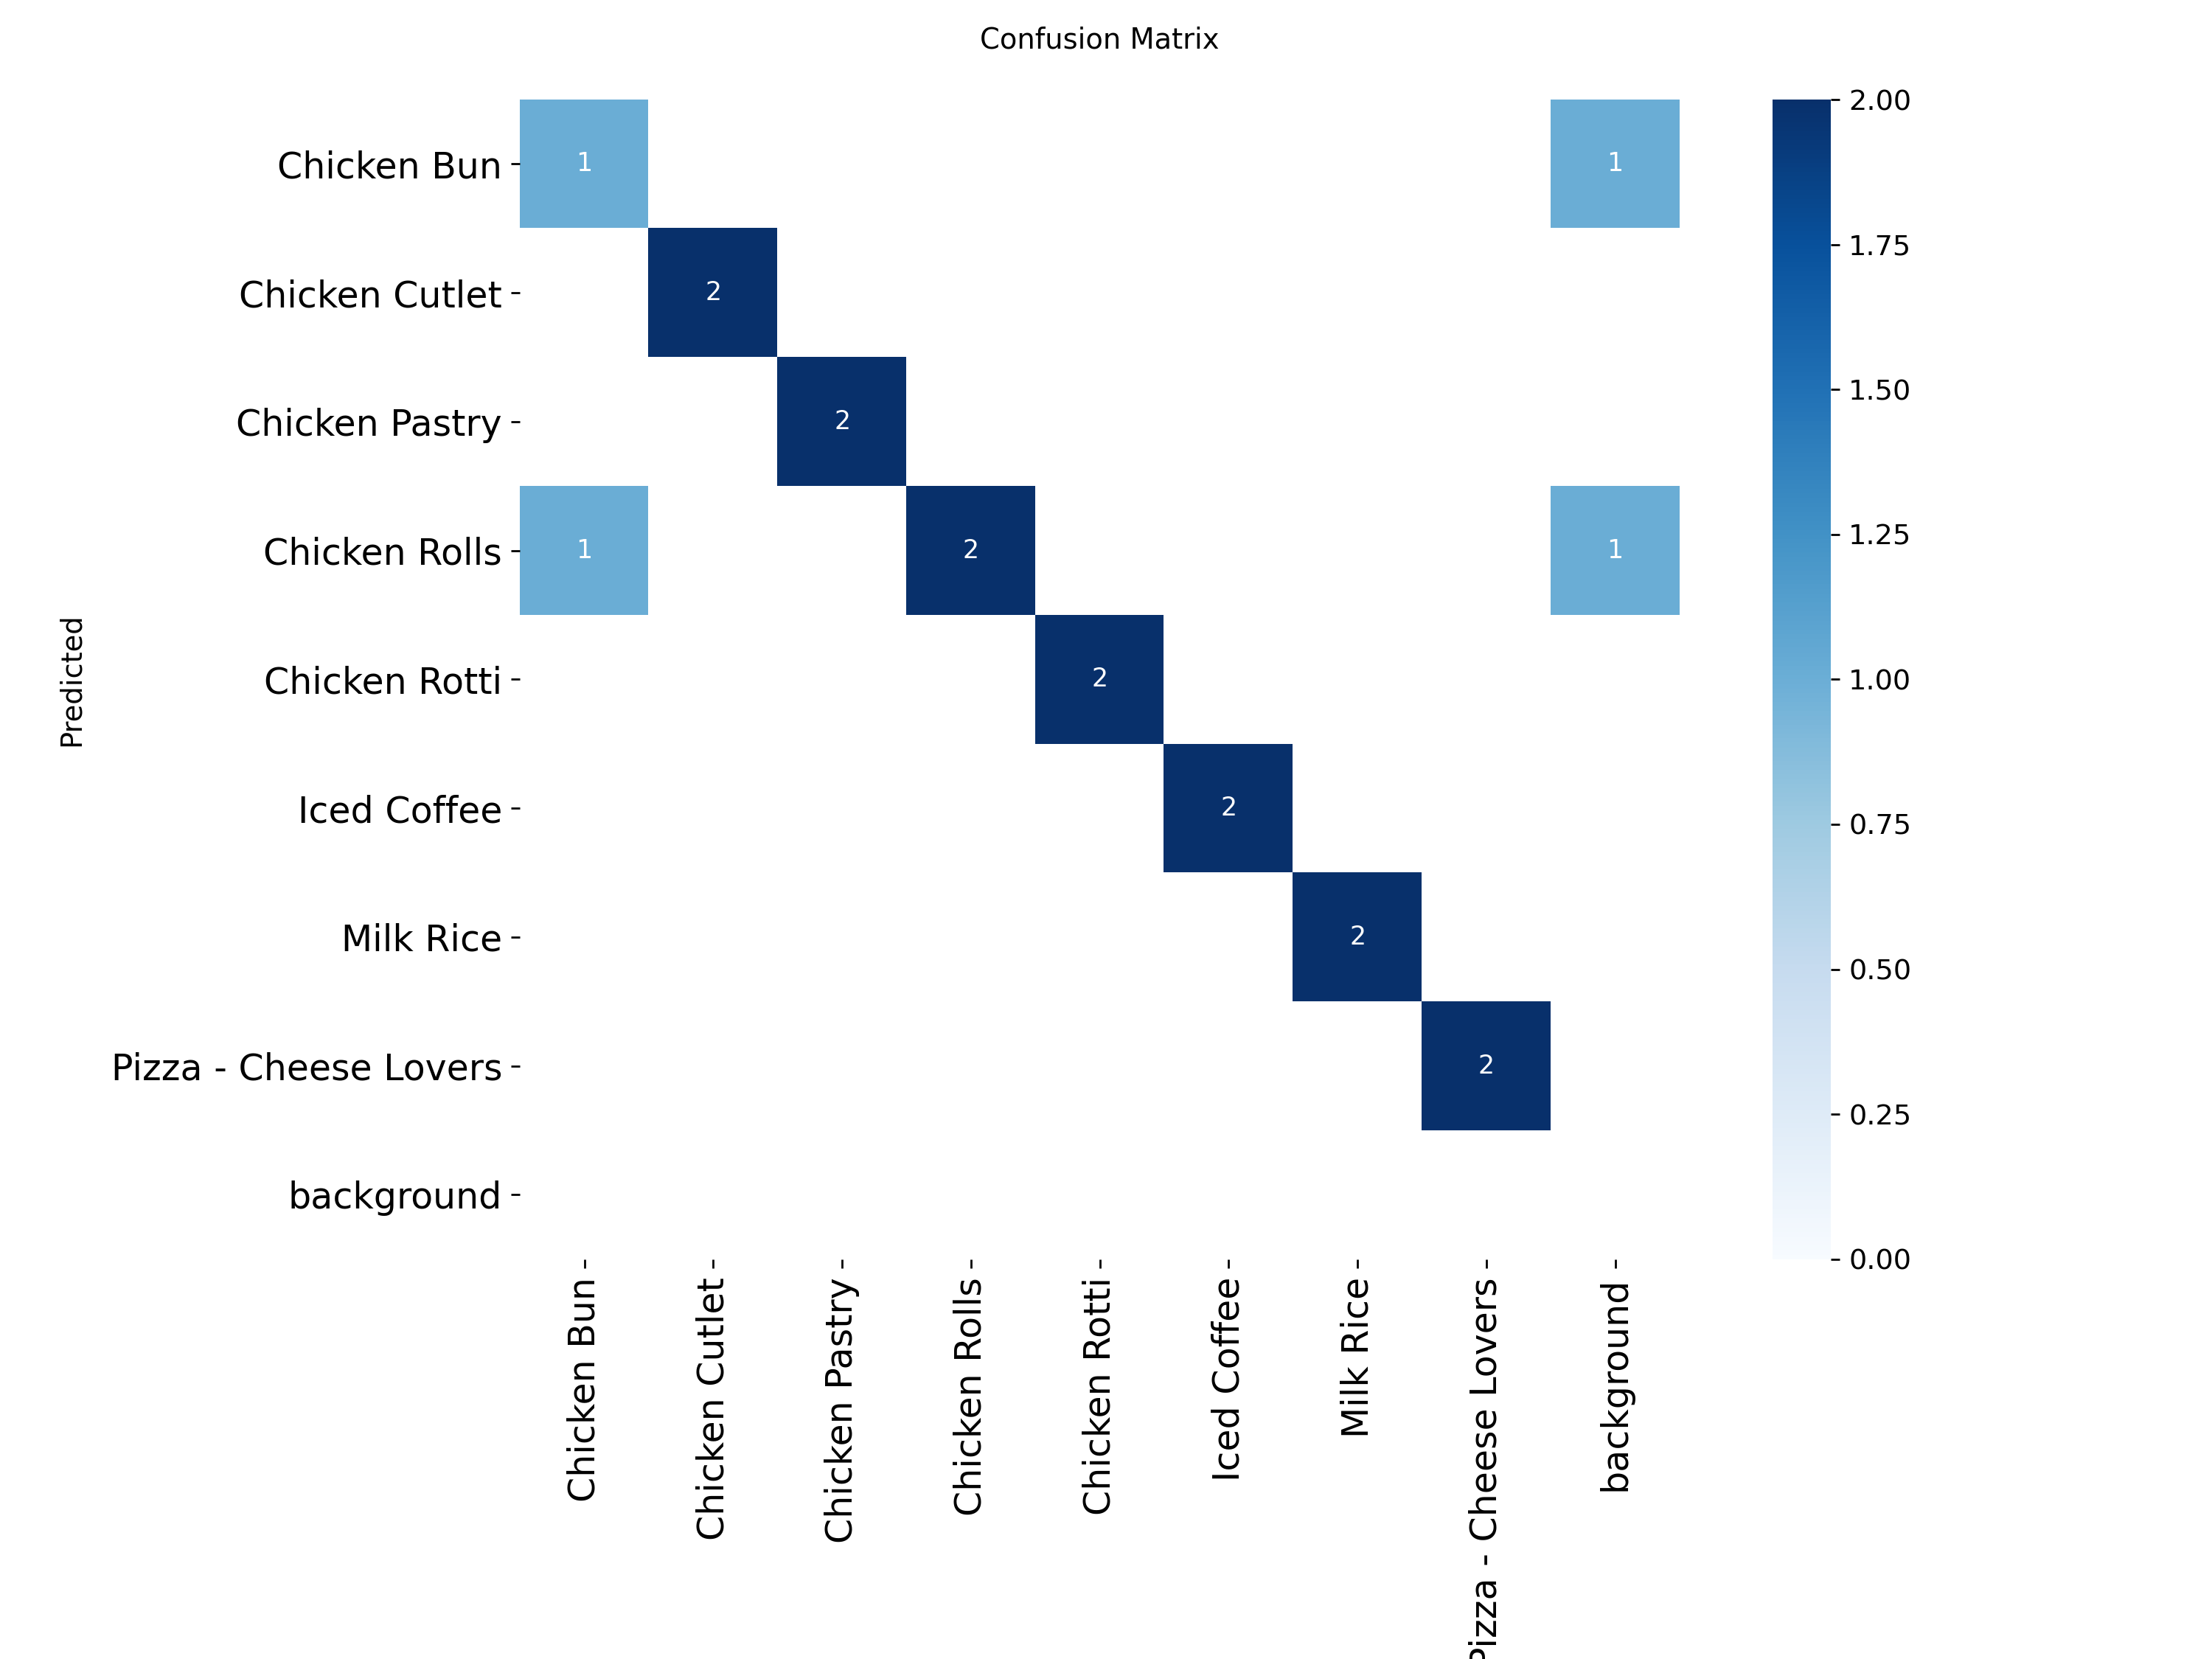


--- BoxPR_curve.png ---


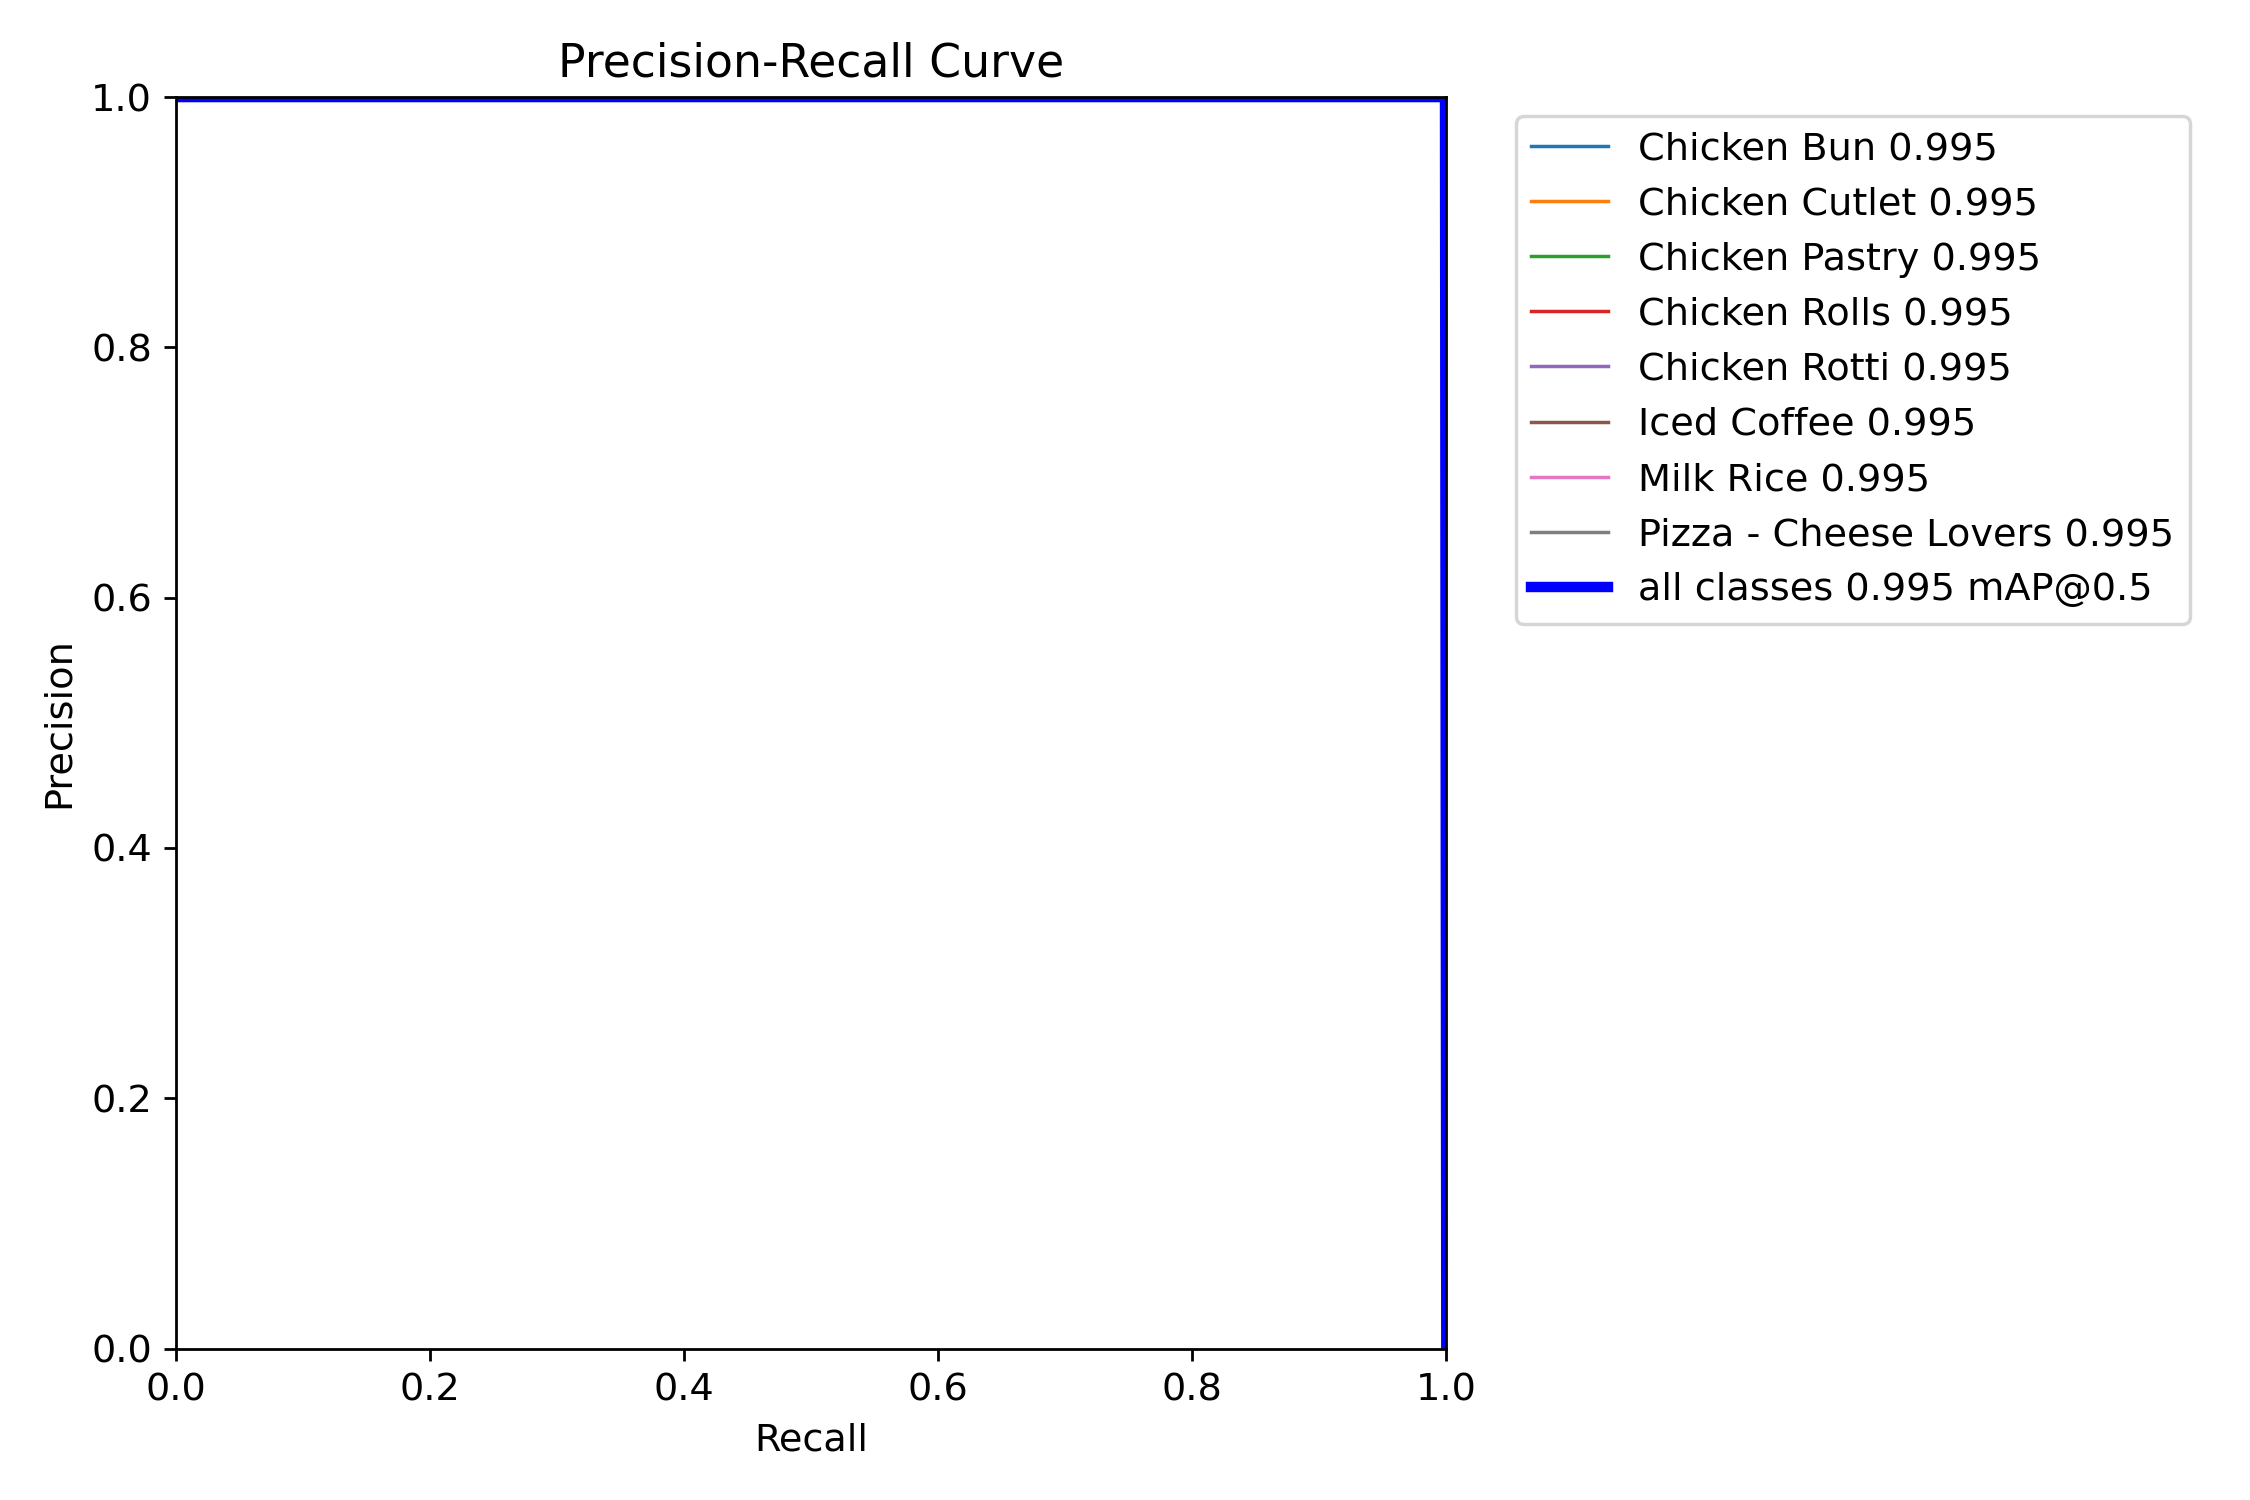


--- BoxF1_curve.png ---


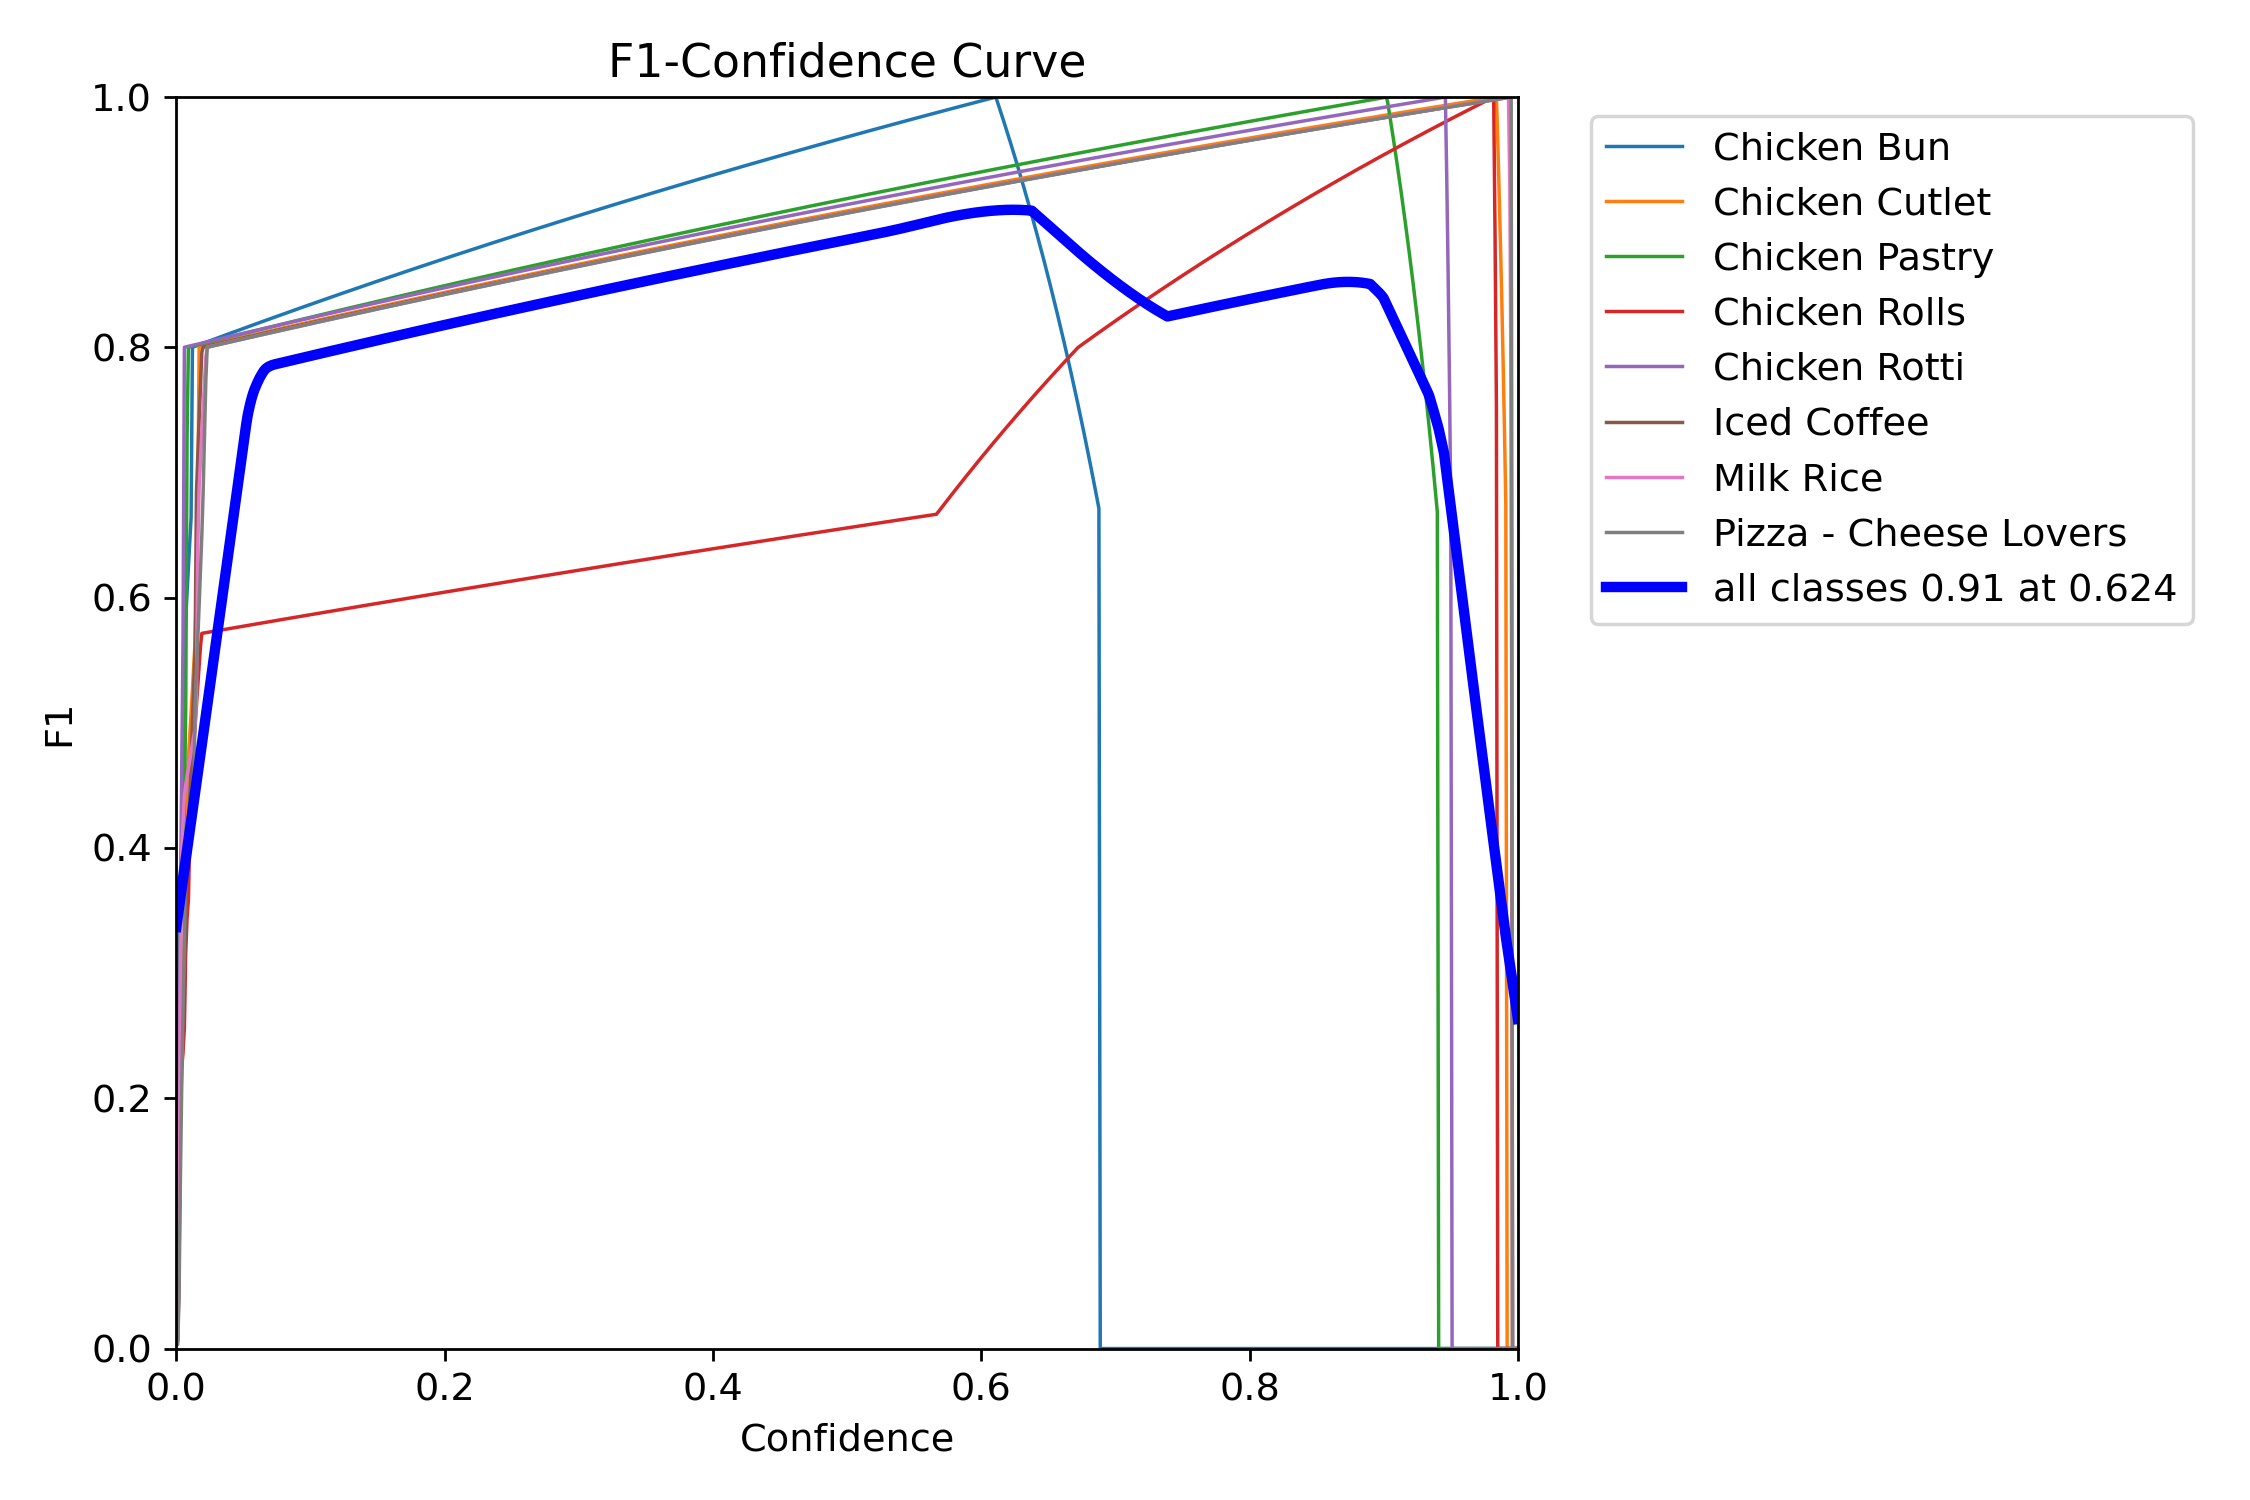


--- BoxP_curve.png ---


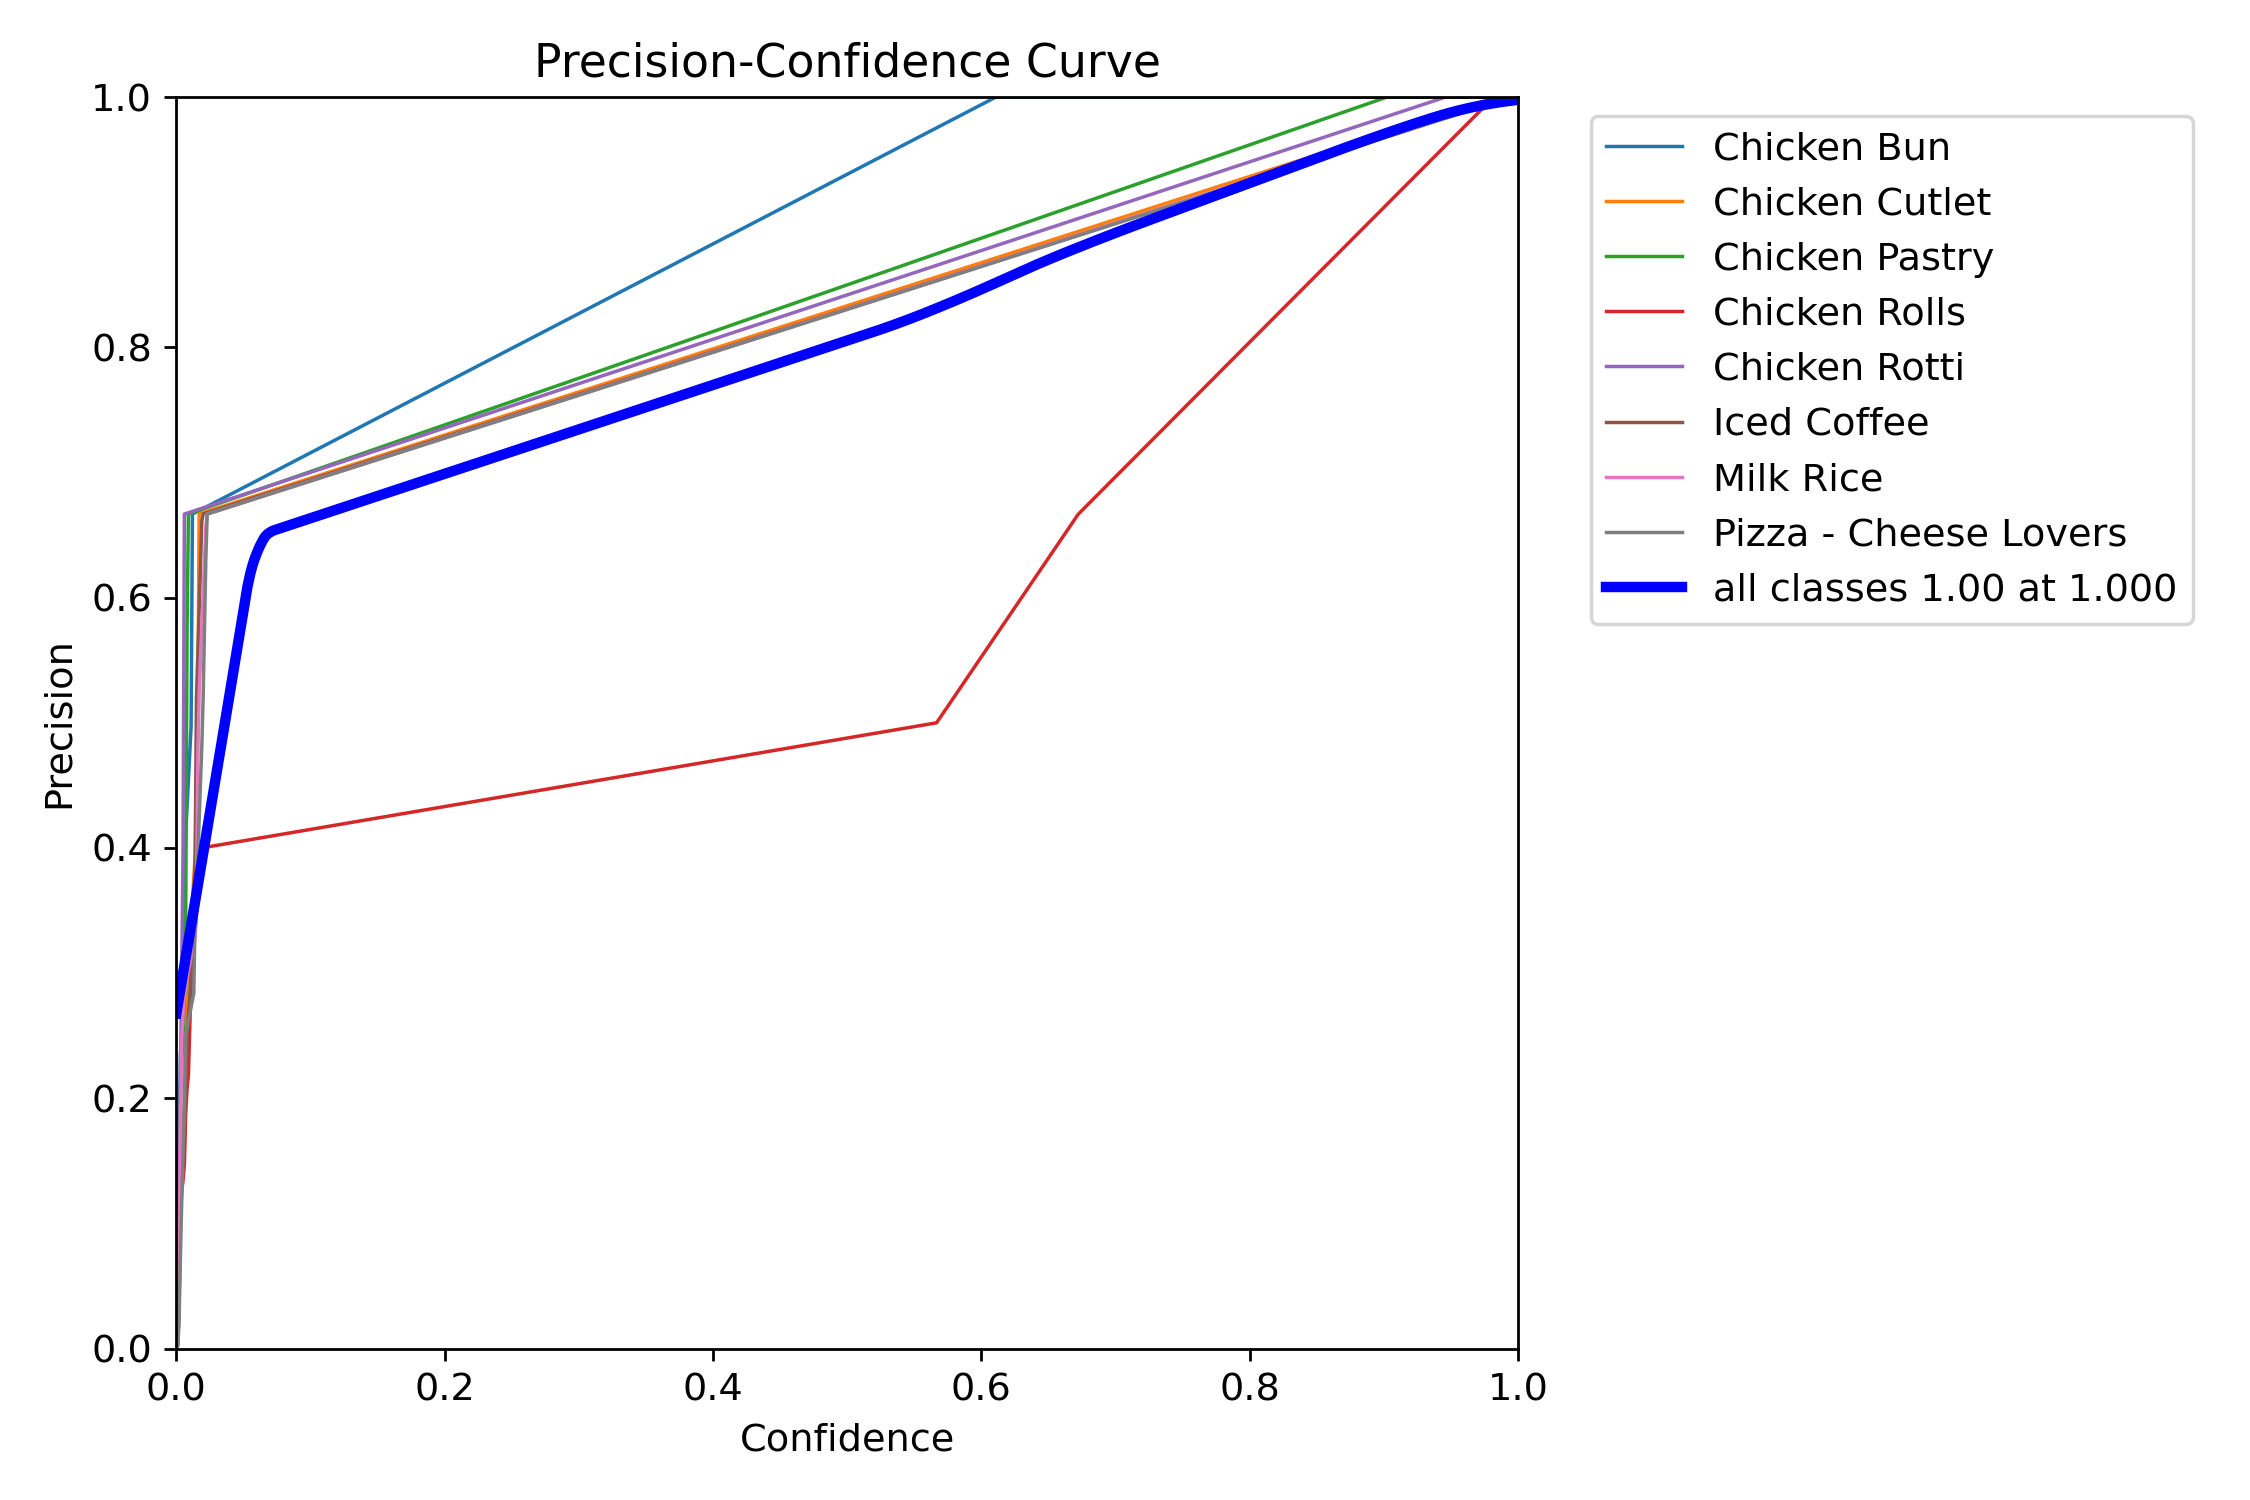


--- BoxR_curve.png ---


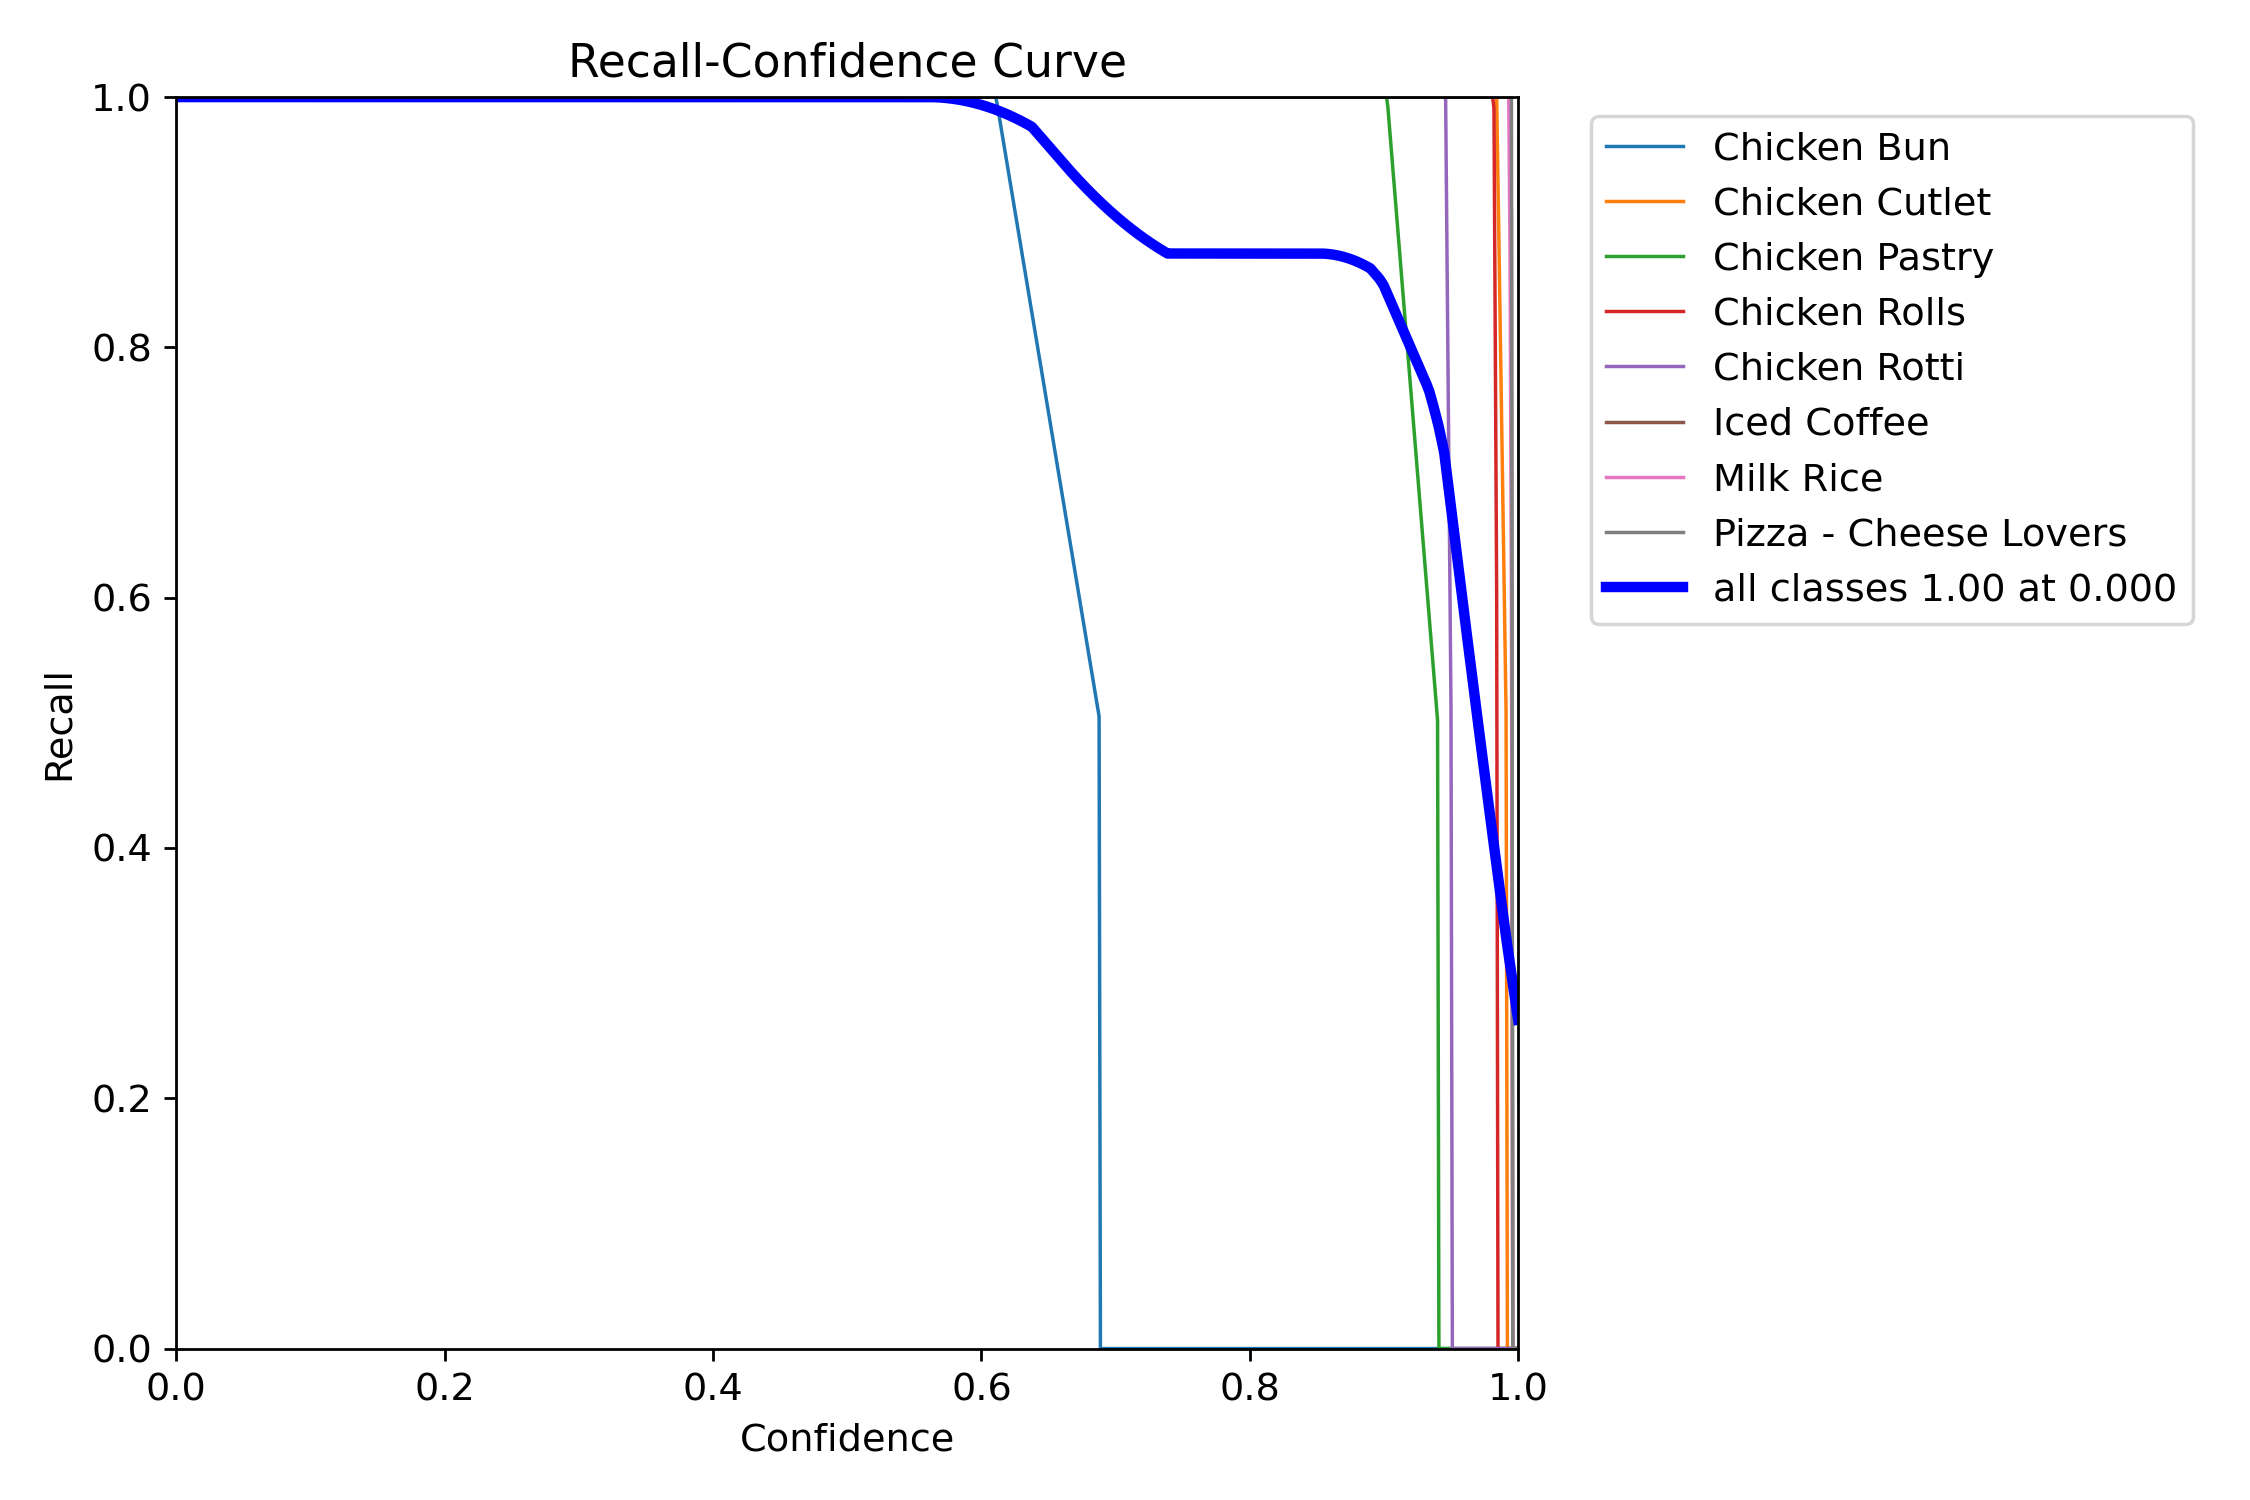

In [11]:
from IPython.display import Image, display
import os

results_dir = "/content/runs/detect/food_detection/yolov8n_run1"

images_to_display = [
    "results.png",
    "confusion_matrix.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for img_name in images_to_display:
    img_path = os.path.join(results_dir, img_name)

    if os.path.exists(img_path):
        print(f"\n--- {img_name} ---")
        display(Image(filename=img_path, width=700))

# Prediction Visualization on Test Images

In [12]:
best_model = YOLO("/content/runs/detect/food_detection/yolov8n_run1/weights/best.pt")

best_model.predict(
    source="/content/drive/MyDrive/Annotated Dataset/test/images",
    save=True,
    conf=0.25
)


image 1/8 /content/drive/MyDrive/Annotated Dataset/test/images/14.jpg: 640x640 1 Chicken Pastry, 254.6ms
image 2/8 /content/drive/MyDrive/Annotated Dataset/test/images/30.jpg: 640x640 1 Chicken Rolls, 263.8ms
image 3/8 /content/drive/MyDrive/Annotated Dataset/test/images/34.jpg: 640x640 1 Pizza - Cheese Lovers, 246.2ms
image 4/8 /content/drive/MyDrive/Annotated Dataset/test/images/41.jpg: 640x640 1 Chicken Cutlet, 243.8ms
image 5/8 /content/drive/MyDrive/Annotated Dataset/test/images/55.jpg: 640x640 1 Chicken Bun, 228.0ms
image 6/8 /content/drive/MyDrive/Annotated Dataset/test/images/58.jpg: 640x640 1 Milk Rice, 241.3ms
image 7/8 /content/drive/MyDrive/Annotated Dataset/test/images/73.jpg: 640x640 1 Chicken Rotti, 247.3ms
image 8/8 /content/drive/MyDrive/Annotated Dataset/test/images/78.jpg: 640x640 1 Iced Coffee, 278.7ms
Speed: 4.0ms preprocess, 250.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Chicken Bun', 1: 'Chicken Cutlet', 2: 'Chicken Pastry', 3: 'Chicken Rolls', 4: 'Chicken Rotti', 5: 'Iced Coffee', 6: 'Milk Rice', 7: 'Pizza - Cheese Lovers'}
 obb: None
 orig_img: array([[[212, 203, 200],
         [212, 203, 200],
         [212, 202, 202],
         ...,
         [195, 183, 183],
         [192, 180, 180],
         [187, 175, 175]],
 
        [[216, 207, 204],
         [216, 207, 204],
         [217, 207, 207],
         ...,
         [201, 189, 189],
         [198, 186, 186],
         [192, 180, 180]],
 
        [[215, 206, 203],
         [216, 207, 204],
         [218, 208, 208],
         ...,
         [206, 194, 194],
         [202, 190, 190],
         [196, 184, 184]],
 
        ...,
 
        [[155, 149, 144],
         [153, 149, 144],
         [153, 149, 144],
         ...,
         [152, 147, 146],
         [152, 1

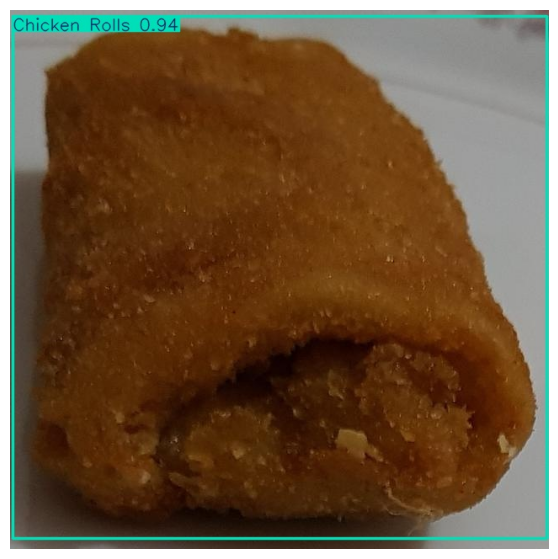

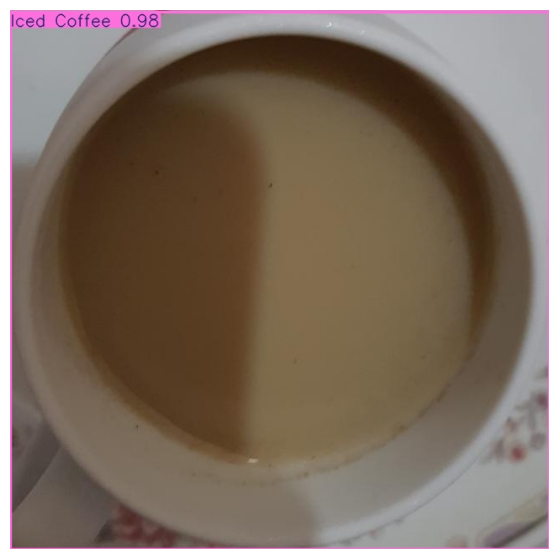

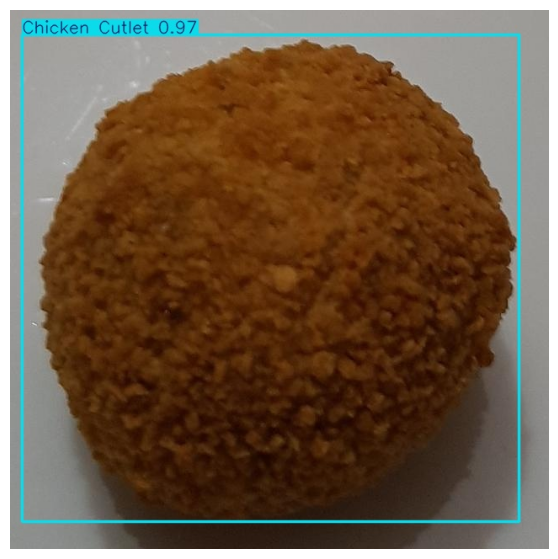

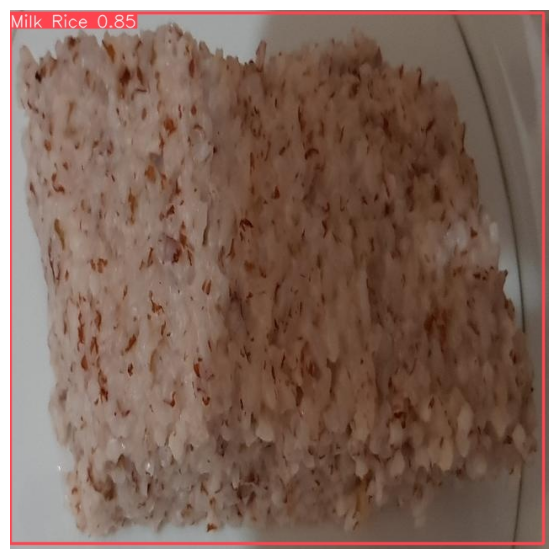

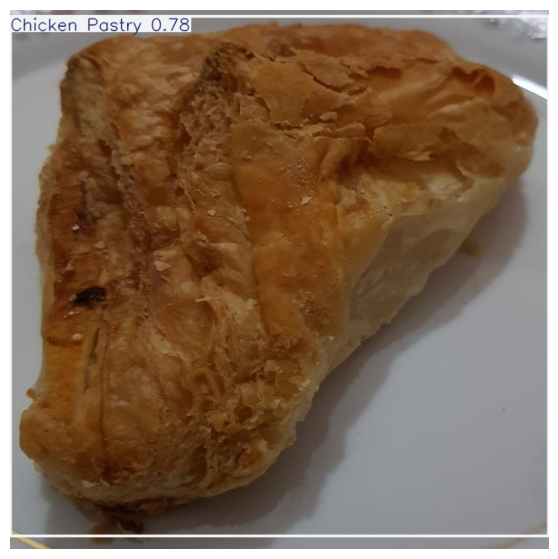

In [13]:
import matplotlib.pyplot as plt
import glob
import cv2

pred_images = glob.glob("/content/runs/detect/predict/*.jpg")

for img_path in pred_images[:5]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [14]:
!zip -r food_detection_run1.zip /content/runs/detect/food_detection/yolov8n_run1
from google.colab import files
files.download("food_detection_run1.zip")

  adding: content/runs/detect/food_detection/yolov8n_run1/ (stored 0%)
  adding: content/runs/detect/food_detection/yolov8n_run1/BoxPR_curve.png (deflated 22%)
  adding: content/runs/detect/food_detection/yolov8n_run1/BoxF1_curve.png (deflated 7%)
  adding: content/runs/detect/food_detection/yolov8n_run1/results.png (deflated 7%)
  adding: content/runs/detect/food_detection/yolov8n_run1/BoxP_curve.png (deflated 10%)
  adding: content/runs/detect/food_detection/yolov8n_run1/val_batch0_labels.jpg (deflated 10%)
  adding: content/runs/detect/food_detection/yolov8n_run1/confusion_matrix_normalized.png (deflated 23%)
  adding: content/runs/detect/food_detection/yolov8n_run1/val_batch0_pred.jpg (deflated 9%)
  adding: content/runs/detect/food_detection/yolov8n_run1/weights/ (stored 0%)
  adding: content/runs/detect/food_detection/yolov8n_run1/weights/last.pt (deflated 9%)
  adding: content/runs/detect/food_detection/yolov8n_run1/weights/best.pt (deflated 9%)
  adding: content/runs/detect/foo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>